# Taller Análisis Exploratorio de Datos

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [UCI](https://archive.ics.uci.edu/dataset/27/credit+approval).

De a las columnas los siguientes nombres: 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15'.

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

cols = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','A15','A16']
df = pd.read_csv('crx.data', header=None, names=cols, na_values='?')
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [ ]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 690
Columnas: 16


In [ ]:
df.dtypes

A1         str
A2     float64
A3     float64
A4         str
A5         str
A6         str
A7         str
A8     float64
A9         str
A10        str
A11      int64
A12        str
A13        str
A14    float64
A15      int64
A16        str
dtype: object

In [ ]:
# A2, A3, A8, A14, A15 son numéricas pero A2, A3 y A14 quedaron como texto (str/object)
# por la presencia de '?' o formatos particulares. Las convertimos a numérico.
for c in ['A2','A3','A8','A11','A14','A15']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df.dtypes

A1         str
A2     float64
A3     float64
A4         str
A5         str
A6         str
A7         str
A8     float64
A9         str
A10        str
A11      int64
A12        str
A13        str
A14    float64
A15      int64
A16        str
dtype: object

**Respuestas:**

- El dataframe tiene **690 filas y 16 columnas** (no 15, ver nota en la introducción del Paso 1).
- Antes de la conversión, `A2`, `A3` y `A14` quedaban tipadas como texto (`object`/`str`) por causa de los `?` (valores faltantes codificados como texto) mezclados con números. `A8`, `A11` y `A15` sí se leyeron directamente como numéricas. Las columnas `A1`, `A4`, `A5`, `A6`, `A7`, `A9`, `A10`, `A12`, `A13` y `A16` son categóricas (texto).
- **No todas las variables tenían el tipo correcto al cargar**: `A2`, `A3` y `A14` debían ser numéricas (continuas, según la descripción del dataset en UCI) pero quedaban como texto por los valores nulos representados con `'?'`. Ya corregimos esto usando `na_values='?'` y `pd.to_numeric`. El resto de tipos sí corresponden a su contenido: variables binarias/categóricas como texto y variables continuas como numéricas.

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
A1,678,2,b,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A2,678.0,NaN,NaN,NaN,31.568171,11.957862,13.75,22.6025,28.46,38.23,80.25
A3,690.0,NaN,NaN,NaN,4.758725,4.978163,0.0,1.0,2.75,7.2075,28.0
A4,684,3,u,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A5,684,3,g,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A6,681,14,c,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A7,681,9,v,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A8,690.0,NaN,NaN,NaN,2.223406,3.346513,0.0,0.165,1.0,2.625,28.5
A9,690,2,t,361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A10,690,2,f,395,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Rangos de las variables cuantitativas
df[['A2','A3','A8','A11','A14','A15']].agg(['min','max'])

,A2,A3,A8,A11,A14,A15
min,13.75,0.0,0.0,0,0.0,0
max,80.25,28.0,28.5,67,2000.0,100000


In [ ]:
# Número de valores únicos por columna (para detectar variables constantes o de alta cardinalidad)
df.nunique().sort_values(ascending=False)

A2     349
A15    240
A3     215
A14    170
A8     132
A11     23
A6      14
A7       9
A4       3
A5       3
A13      3
A1       2
A12      2
A10      2
A9       2
A16      2
dtype: int64

**Respuestas:**

- **Valores fuera de rango:** no se observan valores negativos ni claramente imposibles en las variables cuantitativas (edad `A2` entre 13.75 y 80.25 años, deuda `A3`, ingreso `A15`, etc. son todos ≥ 0, como corresponde). No hay evidencia de valores fuera del dominio esperado a partir de los mínimos y máximos.
- **Variables que no varían:** ninguna. Todas las columnas tienen más de un valor único (la de menor cardinalidad, `A1`, ya tiene 2 valores distintos: `b` y `a`).
- **Variables cualitativas de alta cardinalidad:** `A6` (14 valores únicos) y `A7` (9 valores únicos) son las categóricas con más categorías distintas. El resto de las cualitativas (`A1`, `A4`, `A5`, `A9`, `A10`, `A12`, `A13`, `A16`) tienen entre 2 y 3 categorías, por lo que no se consideran de alta cardinalidad.
- **Claves primarias / identificadores únicos:** no existe ninguna columna con 690 valores únicos (uno por fila), por lo tanto **no hay ninguna variable que actúe como identificador único o clave primaria** en este dataset.

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

In [ ]:
# Como se concluyó en el Paso 2, en este dataset no hay variables constantes ni claves
# primarias que descartar. Tampoco existen columnas 'City' ni 'Lat Long': esas instrucciones
# corresponden a otro dataset de plantilla y no aplican a crx.data, así que seguimos con
# todas las 16 columnas.
nulos = df.isnull().sum()
prop_nulos = (df.isnull().mean() * 100).round(2)
pd.DataFrame({'n_nulos': nulos, 'porcentaje(%)': prop_nulos}).query('n_nulos > 0')

,n_nulos,porcentaje(%)
A1,12,1.74
A2,12,1.74
A4,6,0.87
A5,6,0.87
A6,9,1.30
A7,9,1.30
A14,13,1.88


In [ ]:
# Registros duplicados
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 0


In [ ]:
# Revisión de formateo en variables categóricas (mayúsculas/minúsculas, espacios, etc.)
cat_cols = ['A1','A4','A5','A6','A7','A9','A10','A12','A13','A16']
for c in cat_cols:
    print(c, sorted(df[c].dropna().unique()))

A1 ['a', 'b']
A4 ['l', 'u', 'y']
A5 ['g', 'gg', 'p']
A6 ['aa', 'c', 'cc', 'd', 'e', 'ff', 'i', 'j', 'k', 'm', 'q', 'r', 'w', 'x']
A7 ['bb', 'dd', 'ff', 'h', 'j', 'n', 'o', 'v', 'z']
A9 ['f', 't']
A10 ['f', 't']
A12 ['f', 't']
A13 ['g', 'p', 's']
A16 ['+', '-']


**Respuestas:**

- **Variables con nulos:** `A1` (12 nulos, 1.74%), `A2` (12 nulos, 1.74%), `A4` (6 nulos, 0.87%), `A5` (6 nulos, 0.87%), `A6` (9 nulos, 1.30%), `A7` (9 nulos, 1.30%) y `A14` (13 nulos, 1.88%). En todos los casos la proporción de nulos es baja (menor al 2%).
- **Registros duplicados:** no hay ninguna fila duplicada en el dataframe (`df.duplicated().sum() == 0`).
- **Problemas de formateo:** no se detectan inconsistencias de mayúsculas/minúsculas ni de formato en las variables categóricas (los códigos de letras se mantienen consistentes, p. ej. `A1` solo tiene `b`/`a`). No hay variables de fecha en el dataset. Sí vale la pena mencionar que los valores faltantes venían codificados como el string `'?'` en vez de vacíos — un problema de formateo que ya corregimos en el Paso 1 con `na_values='?'`. Además, `A14` venía con ceros a la izquierda (por ejemplo `00202`), un formato de texto típico de campos tipo "código postal" que al convertir a numérico simplemente se interpreta como el entero correspondiente.

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

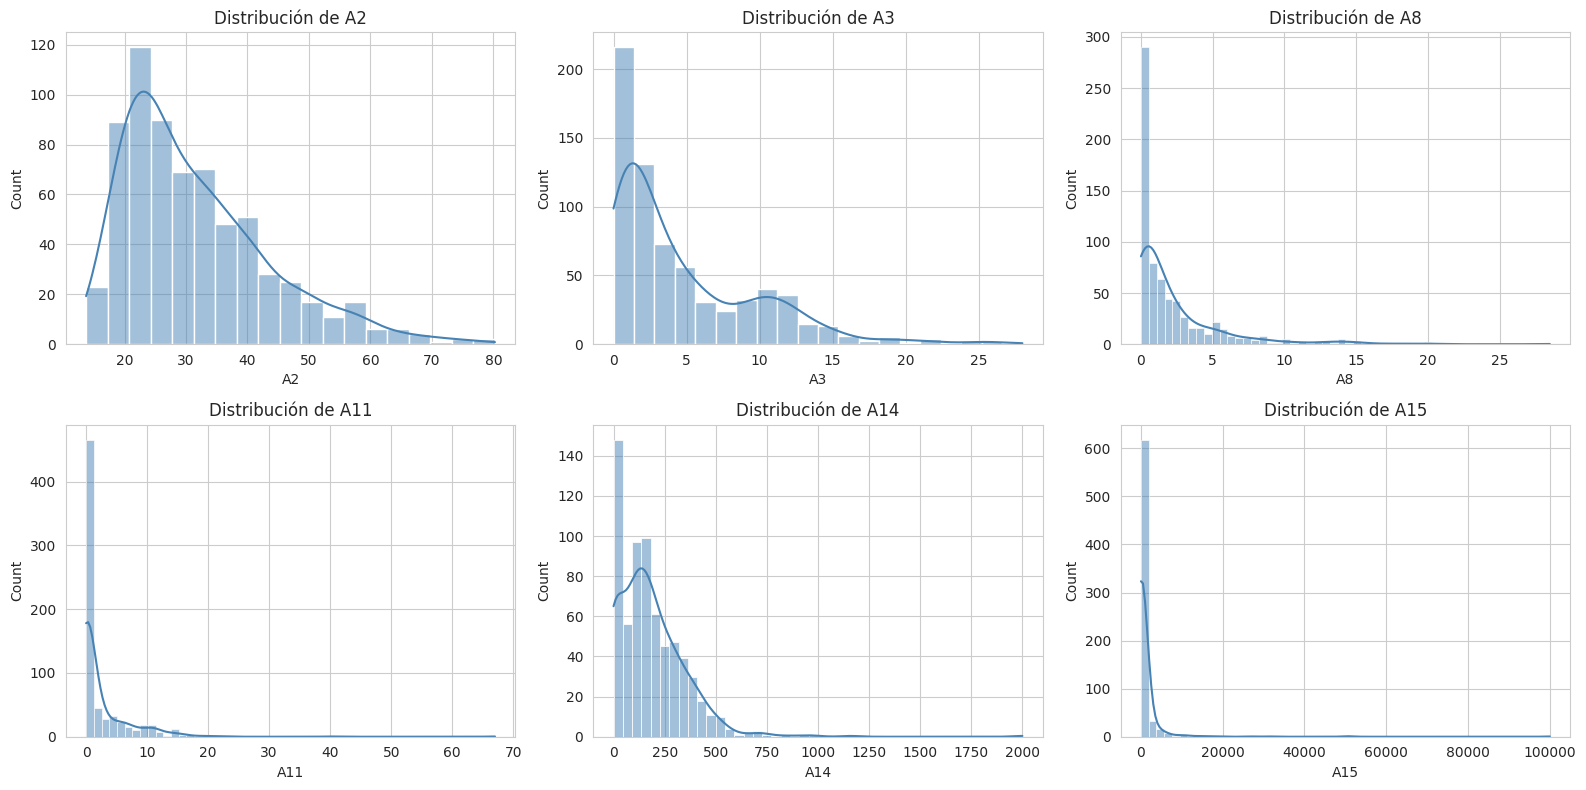

In [ ]:
quant_cols = ['A2','A3','A8','A11','A14','A15']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), quant_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribución de {c}')
plt.tight_layout()
plt.show()

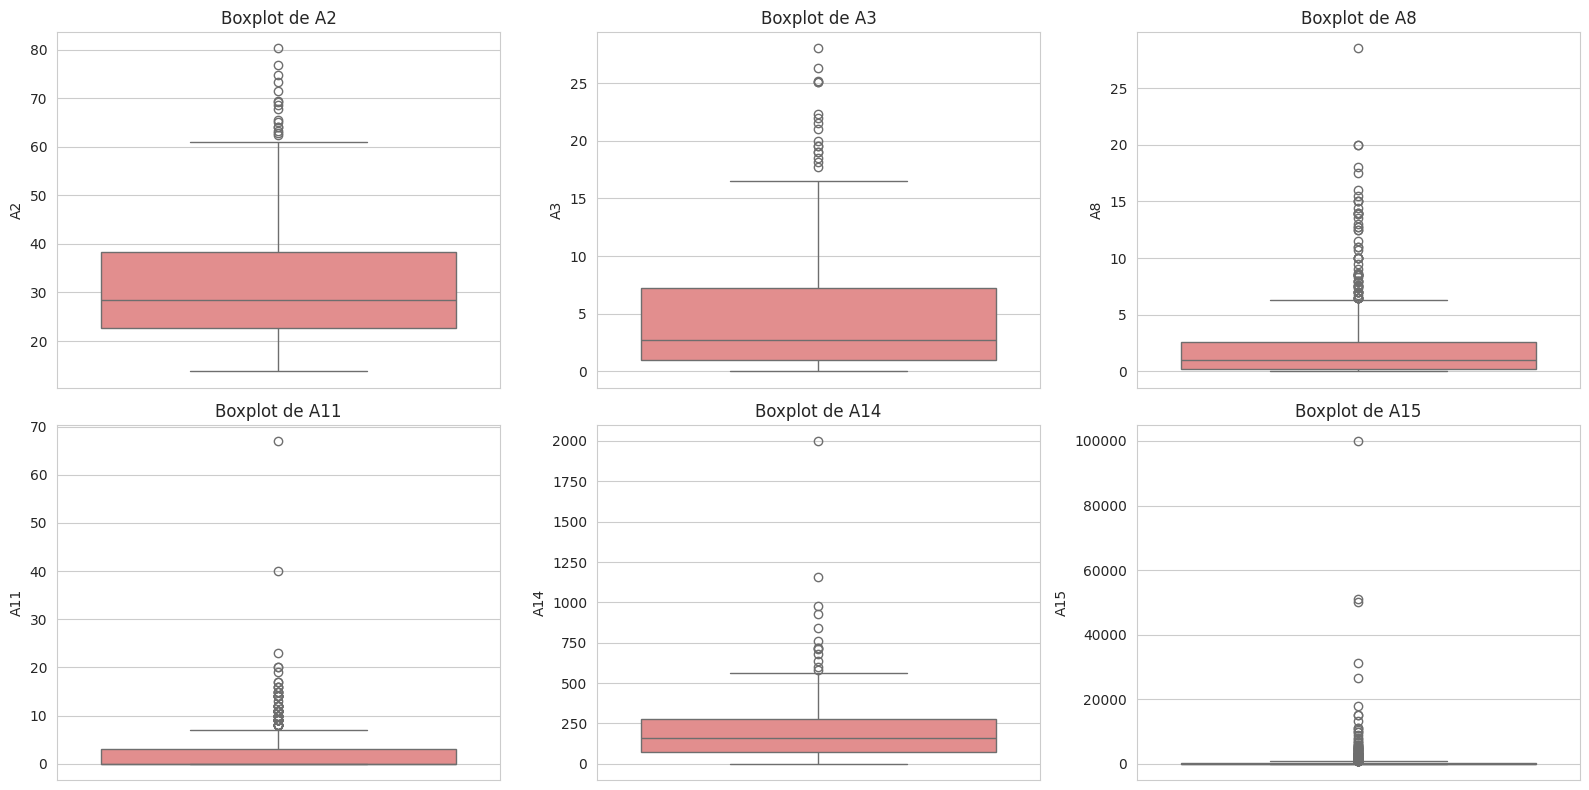

In [ ]:
# Boxplots para detección visual de outliers
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), quant_cols):
    sns.boxplot(y=df[c], ax=ax, color='lightcoral')
    ax.set_title(f'Boxplot de {c}')
plt.tight_layout()
plt.show()

**Análisis de outliers:** todas las variables cuantitativas muestran datos atípicos según el criterio de 1.5×IQR, en distintos grados:

- `A15` (ingreso) es la que más outliers tiene proporcionalmente (~16%), seguida de `A11` (número de tarjetas de crédito activas, ~11%) y `A8` (~9%).
- `A2` (edad) y `A14` tienen relativamente pocos outliers (~2%).

Estos outliers son consistentes con la naturaleza de las variables (unas pocas personas con ingresos, deudas o número de tarjetas mucho más altos que el resto), por lo que no parecen errores de captura sino valores extremos genuinos propios de datos financieros.

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

**Respuestas:**

- **Comportamiento de las variables categóricas:** la mayoría son binarias (`A1`, `A9`, `A10`, `A12`, `A16`) con proporciones razonablemente balanceadas entre sus dos categorías (ninguna está por debajo de ~30%/70%). `A4`, `A5` y `A13` tienen 3 categorías cada una, pero muy desbalanceadas: una categoría domina fuertemente (por ejemplo en `A13`, `g` representa más del 90% de los casos, y `l`/`gg` en `A4`/`A5` aparecen en menos del 1% de los registros).
- **Variables de alta cardinalidad:** como ya se identificó en el Paso 2, `A6` (14 categorías) y, en menor medida, `A7` (9 categorías) son las de mayor cardinalidad. Ninguna categoría domina completamente en `A6` (la más frecuente, `c`, representa ~20%), mientras que en `A7` sí hay una categoría dominante (`v`, ~59%).
- **Categorías atípicas / poco frecuentes:** en `A4` y `A5` la categoría `l`/`gg` aparece en solo 2 de 690 registros (~0.3%), lo cual es un caso claramente minoritario que podría requerir tratamiento especial (agrupación con otra categoría) antes de modelar. En `A6` la categoría `r` aparece en menos del 1% de los casos, y en `A7` las categorías `dd`, `n` y `o` también son muy poco frecuentes (menos del 1.5% cada una).

## Paso 6: Análisis bivariado

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la vaariable **A15**.

Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?

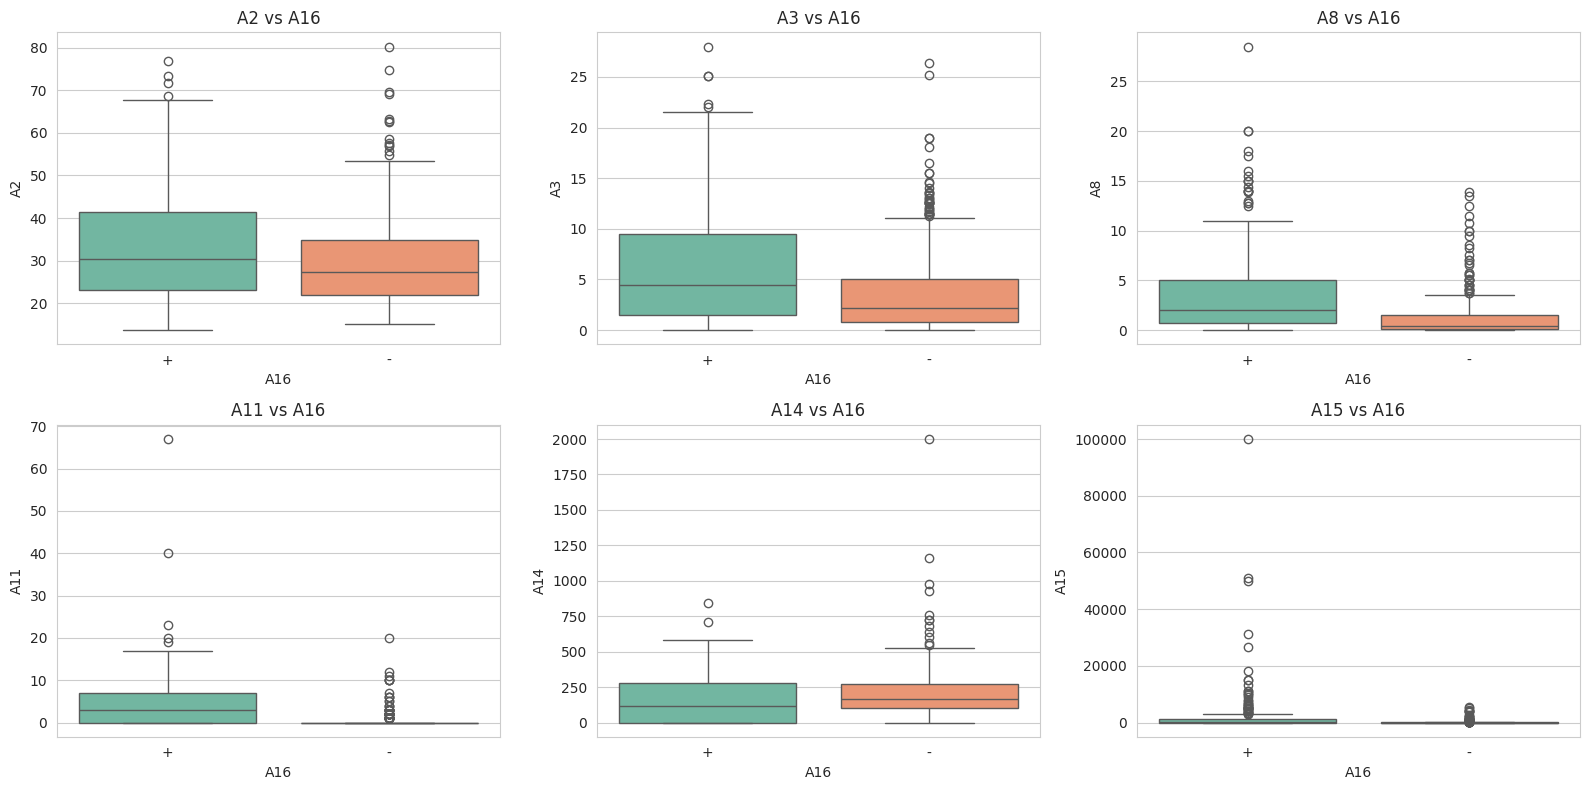

In [ ]:
quant_cols = ['A2','A3','A8','A11','A14','A15']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), quant_cols):
    sns.boxplot(x='A16', y=c, data=df, ax=ax, palette='Set2', hue='A16', legend=False)
    ax.set_title(f'{c} vs A16')
plt.tight_layout()
plt.show()

In [ ]:
df.groupby('A16')[quant_cols].median()

,A2,A3,A8,A11,A14,A15
A16,,,,,,
+,30.50,4.46,2.000,3.0,120.0,221.0
-,27.33,2.21,0.415,0.0,167.5,1.0


**Relación de las variables cuantitativas con A16:**

- `A3` (deuda), `A8` y sobre todo `A11` (número de tarjetas de crédito activas) muestran una diferencia notoria entre las dos clases: los solicitantes aprobados (`+`) tienden a tener valores medianos más altos que los rechazados (`-`). En particular `A11` (mediana 3 vs 0) parece muy informativa.
- `A15` (ingreso) también muestra medianas bastante distintas (221 vs 1), aunque con mucha dispersión y outliers en ambos grupos.
- `A2` (edad) y `A14` muestran diferencias mucho más leves entre clases, con distribuciones bastante superpuestas — de hecho `A14` tiene mediana algo más alta en los rechazados, lo cual sugiere poca relación (o relación débil/contraintuitiva) con la aprobación.

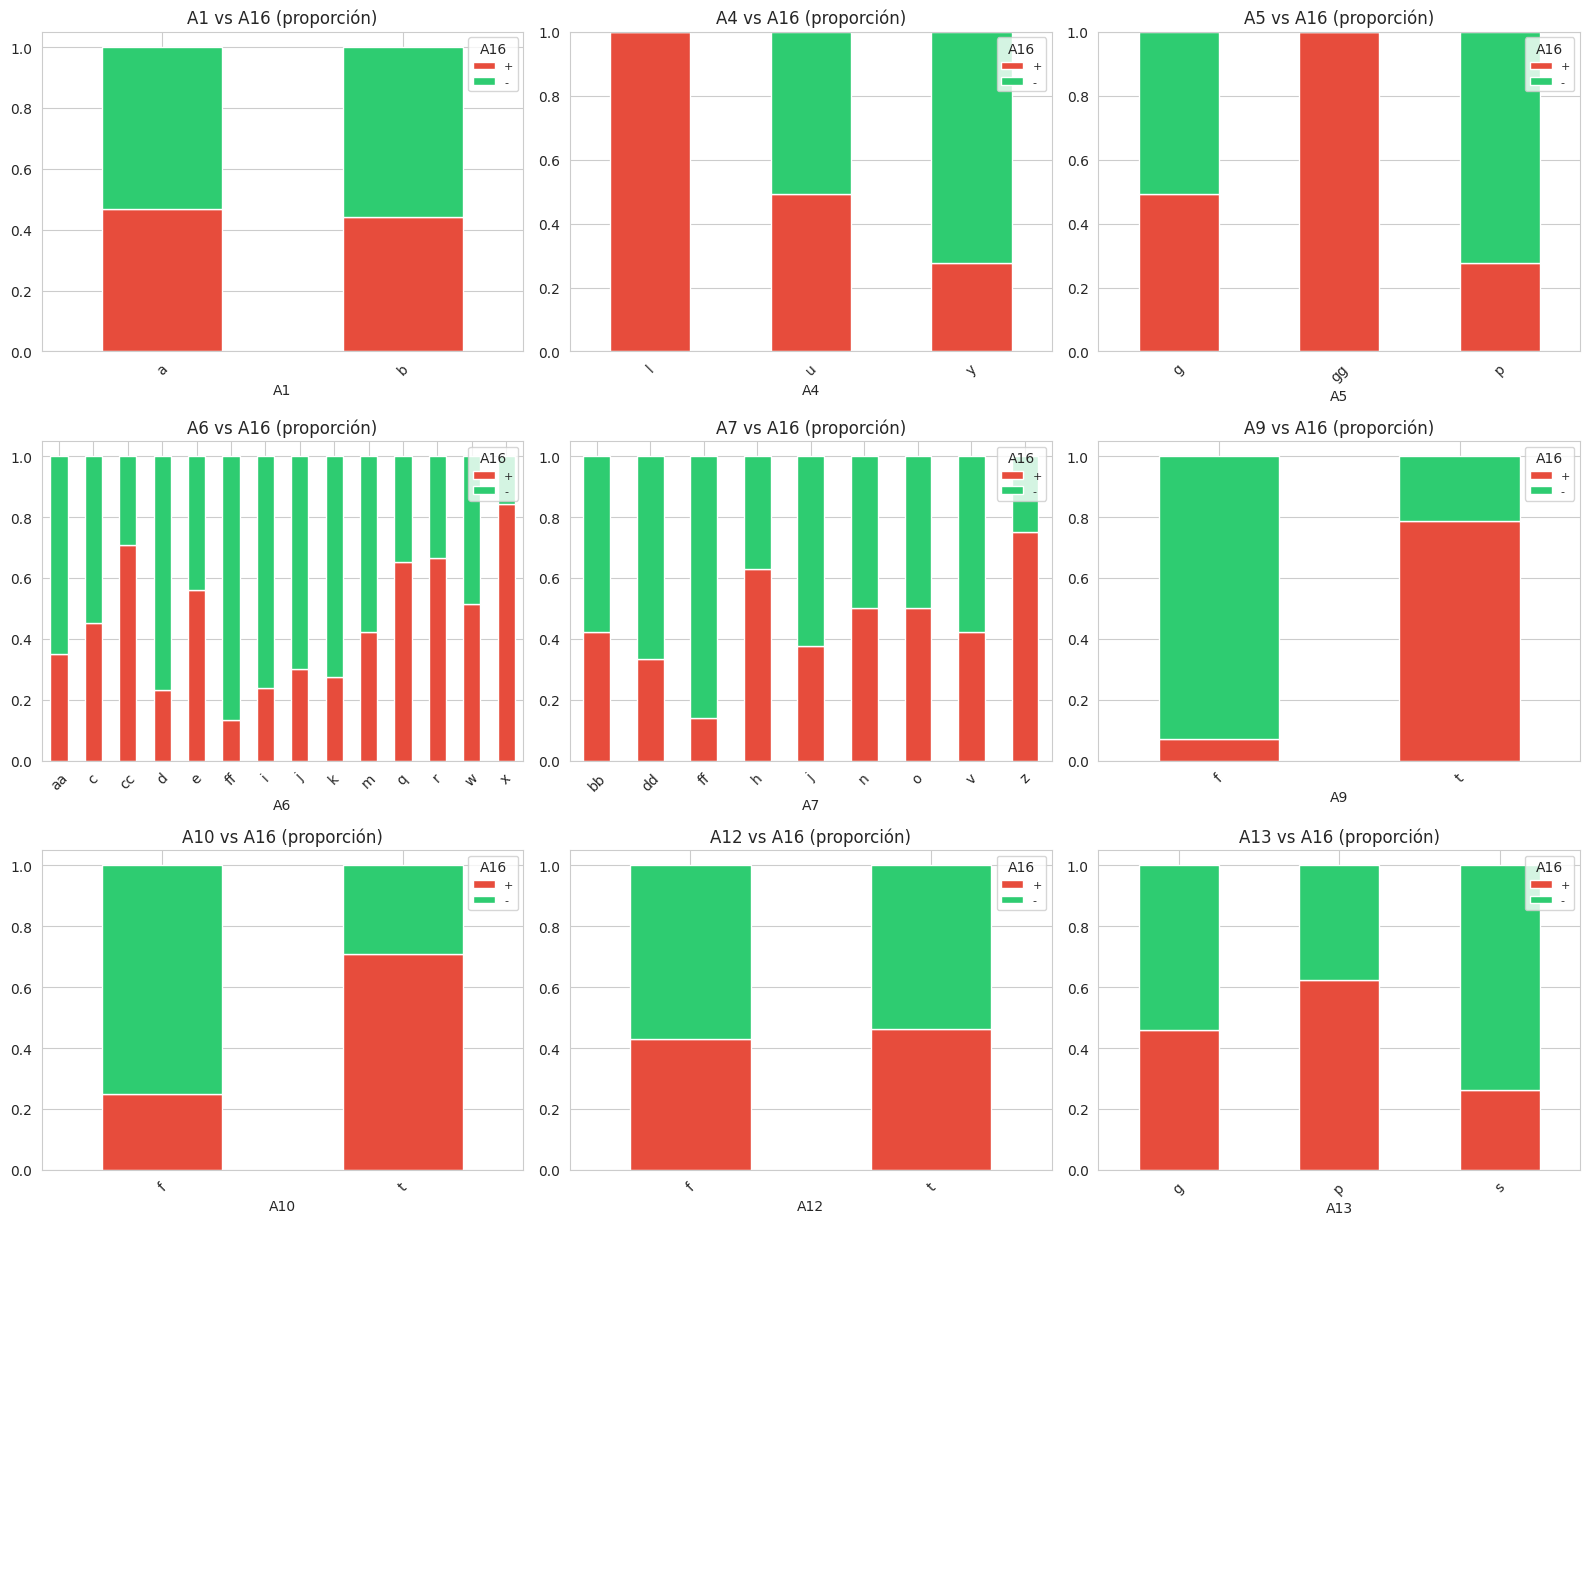

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
cat_predictors = ['A1','A4','A5','A6','A7','A9','A10','A12','A13']
for ax, c in zip(axes.ravel(), cat_predictors):
    ct = pd.crosstab(df[c], df['A16'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c','#2ecc71'])
    ax.set_title(f'{c} vs A16 (proporción)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='A16', fontsize=8)
for ax in axes.ravel()[len(cat_predictors):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Relación de las variables cualitativas con A16:**

- `A9` (tener línea de crédito previa, `t`/`f`) muestra la relación más fuerte y clara con la aprobación: casi todos los que tienen `A9 = t` son aprobados, y casi todos los que tienen `A9 = f` son rechazados. Es, con diferencia, la variable categórica más predictiva.
- `A10` también muestra una asociación notable: quienes tienen `A10 = t` tienen una proporción de aprobación bastante más alta que quienes tienen `A10 = f`.
- `A1`, `A4`, `A5`, `A12` y `A13` muestran proporciones de aprobación bastante parecidas entre sus categorías, por lo que aportan poca información para distinguir la clase.
- `A6` y `A7`, al tener muchas categorías, muestran diferencias más difíciles de interpretar de forma aislada, con algunas categorías con tasas de aprobación más altas que otras, pero sin un patrón tan marcado como el de `A9`/`A10`.

**Conclusión general — variables potencialmente buenas y malas predictoras:**

- **Buenas predictoras:** `A9` y `A10` (categóricas, relación muy marcada con la clase) y, entre las cuantitativas, `A11`, `A3`/`A8` y `A15` (diferencias claras en las medianas entre clases).
- **Predictoras débiles:** `A1`, `A4`, `A5`, `A12`, `A13` (categóricas con distribuciones de aprobación muy similares entre categorías) y `A2`, `A14` (cuantitativas con distribuciones muy superpuestas entre clases).
- `A6` y `A7` requerirían un análisis más detallado (por ejemplo, agrupando categorías poco frecuentes) para aprovechar la información que puedan aportar, dado que tienen alta cardinalidad.